In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
vocab_size = 10000

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [3]:
max_length = 200

X_train = pad_sequences(X_train, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

In [4]:
LSTM_model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),
    Dense(1, activation='sigmoid')
])

LSTM_model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
history = LSTM_model.fit(X_train, y_train, epochs=5, batch_size=64, validation_data=(X_test, y_test))

Epoch 1/5


d:\anaconda\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


391/391 ━━━━━━━━━━━━━━━━━━━━ 96s 240ms/step - accuracy: 0.7717 - loss: 0.4800 - val_accuracy: 0.7679 - val_loss: 0.5200
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 94s 239ms/step - accuracy: 0.8545 - loss: 0.3515 - val_accuracy: 0.8496 - val_loss: 0.3746
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 97s 249ms/step - accuracy: 0.8676 - loss: 0.3181 - val_accuracy: 0.8455 - val_loss: 0.3651
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 136s 235ms/step - accuracy: 0.9062 - loss: 0.2412 - val_accuracy: 0.8571 - val_loss: 0.3972
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 95s 243ms/step - accuracy: 0.9108 - loss: 0.2247 - val_accuracy: 0.8542 - val_loss: 0.3798


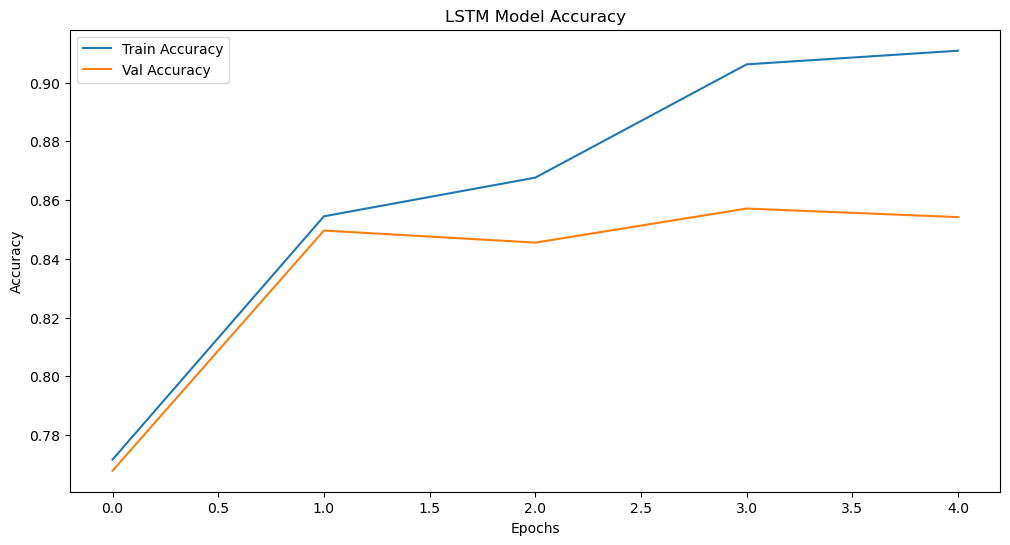

In [5]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('LSTM Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

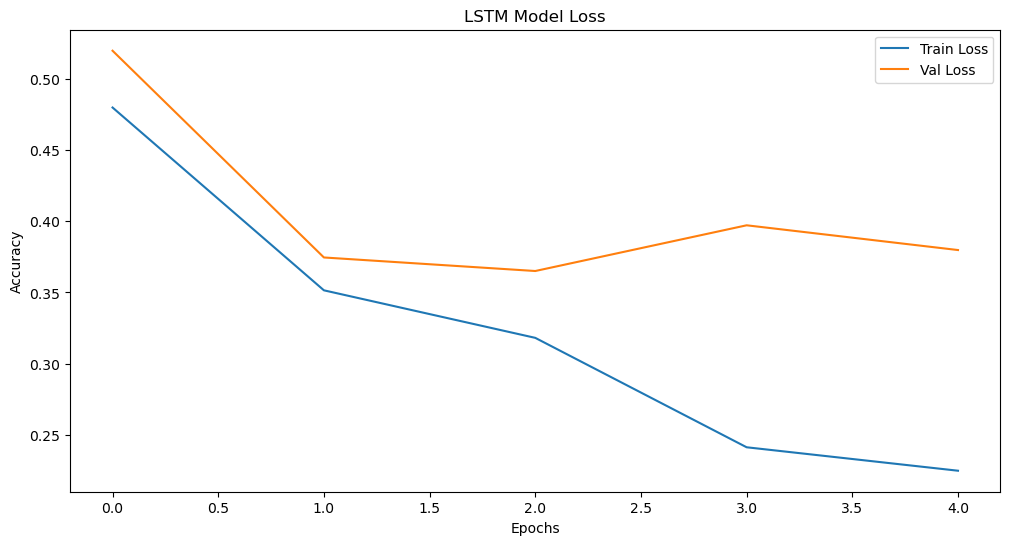

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('LSTM Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()